In [1]:
import os
print(os.path.dirname(os.getcwd()))
os.chdir(os.path.dirname(os.getcwd()))

/home/daniil_gorenkov/wheel_defects


In [2]:
from src.mixins.preprocessor import PreprocessorMixin
from src.mixins.plot_utils import TargetSpaceVisualizer
from src.models.three_head_model import ShortFeaturesConvBlock, LongFeaturesConvBlock
from src.models.lite_baseline import SpeedHead
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import config

prep = PreprocessorMixin()
vis = TargetSpaceVisualizer()

/tmp/ipykernel_17758/320702435.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(target_dist.keys()), y=list(target_dist.values()), palette="viridis")


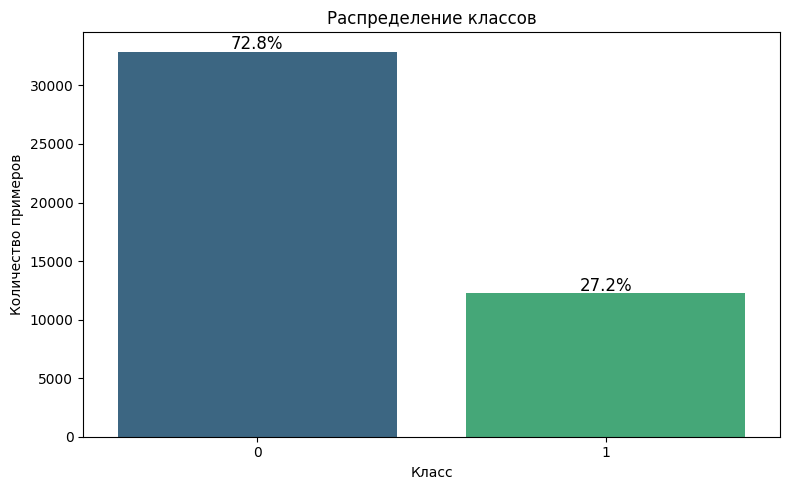

In [3]:
target_dist = {0: 32890, 1: 12285}
total = sum(target_dist.values())

plt.figure(figsize=(8, 5))
sns.barplot(x=list(target_dist.keys()), y=list(target_dist.values()), palette="viridis")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество примеров")

for i, (k, v) in enumerate(target_dist.items()):
    pct = v / total * 100
    plt.text(i, v + 200, f"{pct:.1f}%", ha="center", fontsize=12)

plt.tight_layout()
plt.show()

In [4]:
samples = prep.load_samples("prep_data")
samples[0]

{'X': array([-0.5,  0.7,  0.5,  0.5,  0.6, -1.1,  0.8,  1. , -0.5,  0.7, -1.4,
        -2.4,  1.3, -1. ,  0.8, -0.9,  0.7, -0.6,  0.5,  0.6,  1. , -1. ,
         0.7, -0.5, -0.5,  0.9,  0.8,  0.5, -0.9, -0.5, -0.6,  0.6,  0.5,
         0.7,  0.5, -1.1,  0.5,  0.5]),
 'speed': array([11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28, 11.28,
        11.28, 11.28]),
 'target': 1}

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Данные в пространстве'}, xlabel='Компонента 1', ylabel='Компонента 2'>)

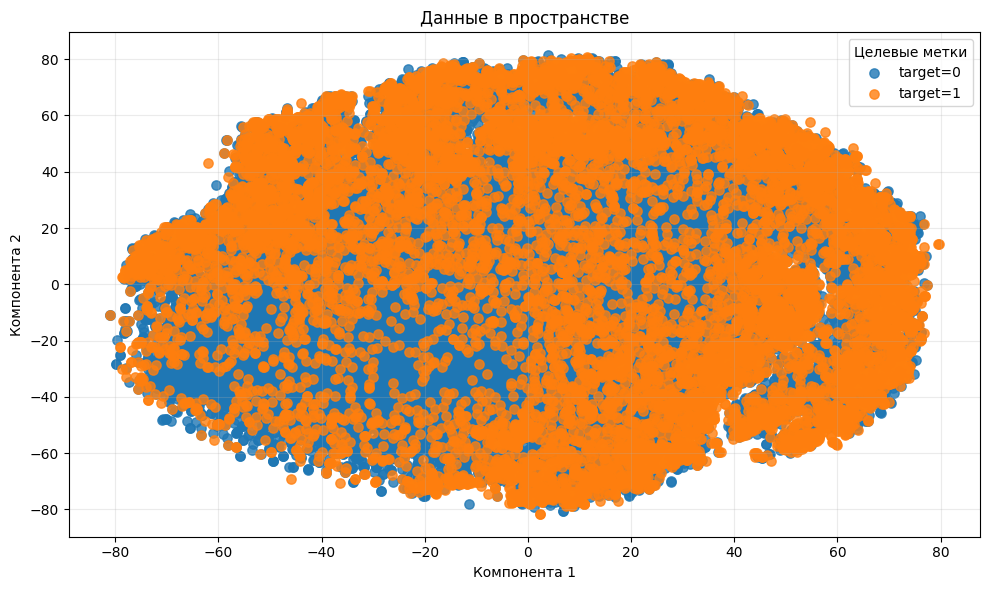

In [5]:
vis.plot(samples,"Данные в пространстве")

In [ ]:
res = prep.preprocess()
res[0]

In [ ]:
import torch

signal = torch.tensor(res[0]["X"],dtype=torch.float32)
speed = torch.tensor(res[0]["speed"],dtype=torch.float32)

In [ ]:
speed.unsqueeze(0).unsqueeze(0).shape